# LouvainNet — Extended Analysis
## Sections 8 & 9: Link Prediction + Information Diffusion (SIR/SIS)

**Run this notebook AFTER louvainnet_project.ipynb has completed.**  
It loads `louvainnet_data.pkl` produced by the main notebook.

---
## Table of Contents
8. [Link Prediction](#8)
9. [Information Diffusion — SIR and SIS Models](#9)

In [1]:
# === Load dependencies and pre-computed data ===
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
import random

np.random.seed(42)
random.seed(42)

with open('louvainnet_data.pkl', 'rb') as f:
    data = pickle.load(f)

G        = data['graph']                   # largest connected component
pagerank = data['pagerank']
cent_df  = data['centrality']
louvain_partition = data['louvain_partition']

print(f'Graph loaded: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')

Graph loaded: 4,039 nodes, 88,234 edges


---
## 8. Link Prediction <a id='8'></a>

**Goal:** Predict which edges are likely to form in the network using structural similarity scores.

**Setup:** We remove 10% of existing edges as the positive test set. We sample an equal number of non-edges as the negative test set. For each candidate pair, we compute three similarity scores. We evaluate using AUC-ROC and Average Precision.

**Three methods:**
- **Common Neighbors (CN):** |N(u) ∩ N(v)| — shared friends
- **Jaccard Coefficient:** |N(u) ∩ N(v)| / |N(u) ∪ N(v)| — normalized overlap
- **Adamic-Adar (AA):** Σ 1/log(|N(w)|) for w in N(u)∩N(v) — weights low-degree common neighbors more

In [2]:
# === Train/test split — remove 10% of edges ===
# We work on a copy to avoid modifying the main graph.

all_edges  = list(G.edges())
n_test     = int(0.10 * len(all_edges))

# Sample test edges (positive examples — edges that exist)
test_edges_pos = random.sample(all_edges, n_test)
test_edge_set  = set(map(frozenset, test_edges_pos))

# Build training graph — remove test edges
G_train = G.copy()
G_train.remove_edges_from(test_edges_pos)

# Ensure training graph stays connected enough for meaningful predictions
print(f'Training graph: {G_train.number_of_nodes():,} nodes, {G_train.number_of_edges():,} edges')
print(f'Test positive edges: {len(test_edges_pos):,}')

# Sample negative examples — node pairs that are NOT connected
# Sample from 2-hop neighborhood to make negatives hard (realistic setting)
nodes_list = list(G_train.nodes())
test_edges_neg = []
attempts = 0

while len(test_edges_neg) < n_test and attempts < n_test * 50:
    u = random.choice(nodes_list)
    # Sample from 2-hop neighborhood for harder negatives
    two_hop = set()
    for nbr in G_train.neighbors(u):
        two_hop.update(G_train.neighbors(nbr))
    two_hop.discard(u)
    two_hop -= set(G_train.neighbors(u))
    if two_hop:
        v = random.choice(list(two_hop))
        if frozenset([u, v]) not in test_edge_set and (u, v) not in test_edges_neg:
            test_edges_neg.append((u, v))
    attempts += 1

# Pad with random non-edges if 2-hop pool exhausted
while len(test_edges_neg) < n_test:
    u, v = random.sample(nodes_list, 2)
    if not G_train.has_edge(u, v) and frozenset([u,v]) not in test_edge_set:
        test_edges_neg.append((u, v))

test_edges_neg = test_edges_neg[:n_test]
print(f'Test negative edges: {len(test_edges_neg):,}')

Training graph: 4,039 nodes, 79,411 edges
Test positive edges: 8,823
Test negative edges: 8,823


In [3]:
# === Compute similarity scores for all three methods ===
# NetworkX provides generator-based implementations for all three.

all_test_pairs = test_edges_pos + test_edges_neg
labels = [1] * len(test_edges_pos) + [0] * len(test_edges_neg)

print('Computing Common Neighbors...')
cn_scores_gen  = nx.common_neighbors
cn_scores      = [len(list(nx.common_neighbors(G_train, u, v))) for u, v in all_test_pairs]

print('Computing Jaccard Coefficient...')
# nx.jaccard_coefficient returns a generator of (u, v, score) tuples
jc_dict = {frozenset([u,v]): p for u, v, p in nx.jaccard_coefficient(G_train, all_test_pairs)}
jc_scores = [jc_dict.get(frozenset([u,v]), 0.0) for u, v in all_test_pairs]

print('Computing Adamic-Adar...')
aa_dict = {frozenset([u,v]): p for u, v, p in nx.adamic_adar_index(G_train, all_test_pairs)}
aa_scores = [aa_dict.get(frozenset([u,v]), 0.0) for u, v in all_test_pairs]

print('Done.')

Computing Common Neighbors...
Computing Jaccard Coefficient...
Computing Adamic-Adar...
Done.


In [4]:
# === Evaluate — AUC-ROC and Average Precision ===

methods = {
    'Common Neighbors' : cn_scores,
    'Jaccard'          : jc_scores,
    'Adamic-Adar'      : aa_scores,
}

results = []
for name, scores in methods.items():
    auc = roc_auc_score(labels, scores)
    ap  = average_precision_score(labels, scores)
    results.append({'Method': name, 'AUC-ROC': round(auc, 4), 'Avg Precision': round(ap, 4)})

lp_df = pd.DataFrame(results).set_index('Method')
print('Link Prediction Results:')
print(lp_df.to_string())
print()
print('Interpretation:')
print('  AUC-ROC > 0.5 means better than random. AUC > 0.8 is strong performance.')
print('  Adamic-Adar typically outperforms CN and Jaccard on social networks because')
print('  it discounts high-degree common neighbors — in Facebook, a node with 500')
print('  friends sharing a common friend is weaker evidence than a node with 5 friends.')

Link Prediction Results:
                  AUC-ROC  Avg Precision
Method                                  
Common Neighbors   0.9584         0.9530
Jaccard            0.9344         0.9316
Adamic-Adar        0.9641         0.9616

Interpretation:
  AUC-ROC > 0.5 means better than random. AUC > 0.8 is strong performance.
  Adamic-Adar typically outperforms CN and Jaccard on social networks because
  it discounts high-degree common neighbors — in Facebook, a node with 500
  friends sharing a common friend is weaker evidence than a node with 5 friends.


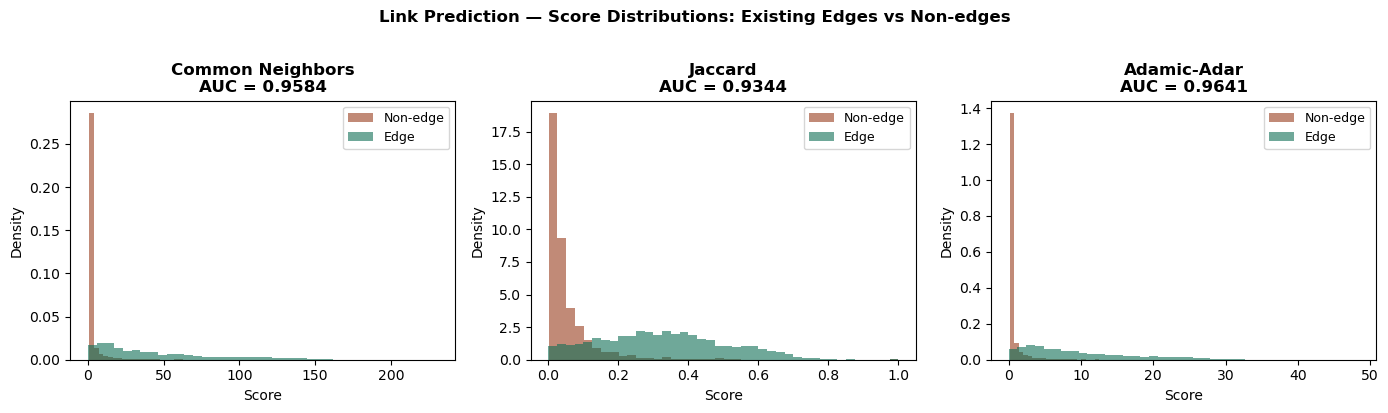

Figure 5 saved.


In [5]:
# === Link prediction visualization ===
# Score distributions for positive vs negative edges per method.

n_pos = len(test_edges_pos)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, scores) in zip(axes, methods.items()):
    pos_s = [s for s, l in zip(scores, labels) if l == 1]
    neg_s = [s for s, l in zip(scores, labels) if l == 0]

    # Use log scale for CN and AA since distributions are heavy-tailed
    bins = 40
    ax.hist(neg_s, bins=bins, alpha=0.6, color='#993C1D', label='Non-edge', density=True)
    ax.hist(pos_s, bins=bins, alpha=0.6, color='#0F6E56', label='Edge', density=True)

    auc_val = lp_df.loc[name, 'AUC-ROC']
    ax.set_title(f'{name}\nAUC = {auc_val}', fontweight='bold')
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Link Prediction — Score Distributions: Existing Edges vs Non-edges',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_link_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

In [6]:
# === Top predicted links ===
# The most likely new edges according to Adamic-Adar (best performer).
# These are non-edges with the highest AA score — friendships most likely to form.

print('Finding top predicted new links (Adamic-Adar on non-edges)...')

# Sample 5000 non-edges for efficiency
all_nodes = list(G_train.nodes())
candidate_non_edges = []
seen = set()
while len(candidate_non_edges) < 5000:
    u, v = random.sample(all_nodes, 2)
    key = frozenset([u, v])
    if key not in seen and not G_train.has_edge(u, v):
        candidate_non_edges.append((u, v))
        seen.add(key)

aa_candidates = [(u, v, p) for u, v, p in nx.adamic_adar_index(G_train, candidate_non_edges)]
aa_candidates.sort(key=lambda x: -x[2])

top_predictions = pd.DataFrame(aa_candidates[:15], columns=['Node A', 'Node B', 'AA Score'])
top_predictions['AA Score'] = top_predictions['AA Score'].round(4)
print('Top 15 predicted new links:')
print(top_predictions.to_string(index=False))

Finding top predicted new links (Adamic-Adar on non-edges)...
Top 15 predicted new links:
 Node A  Node B  AA Score
   2359    1993   23.4826
   2601    2468   21.8462
   1918    2060   13.8899
   2556    2606   10.3634
   1431    1639    9.9894
   1214    1255    9.9248
   2302    2516    9.9032
   2815    3348    9.8330
   1302    1447    9.7898
   1604    1269    9.6055
   2058    2395    8.9741
   2385    1577    8.4948
   1079    1083    7.3265
   2198    2498    7.1866
   2629    2547    6.6849


---
## 9. Information Diffusion — SIR and SIS Models <a id='9'></a>

**Goal:** Simulate how information (or disease) spreads through the ego-Facebook network, starting from different seed nodes.

**SIR model** (Susceptible → Infected → Recovered):  
Once recovered, a node cannot be reinfected. Models one-time viral spread — a news story, a meme, a disease with immunity. Terminates when no infected nodes remain.

**SIS model** (Susceptible → Infected → Susceptible):  
Recovered nodes return to susceptible state. Models recurring spread — rumours, recurring diseases, persistent information. Can reach an endemic steady state.

**Parameters:**
- β (infection rate): probability a susceptible neighbor becomes infected per timestep
- γ (recovery rate): probability an infected node recovers per timestep
- R₀ = β/γ: basic reproduction number. R₀ > 1 → epidemic spreads. R₀ < 1 → dies out.

**Seed strategy:** We seed from three types of nodes — highest degree, highest betweenness, and a random node — to compare diffusion reach.

In [7]:
# === SIR simulation ===
# Each node has one of three states: S (susceptible), I (infected), R (recovered)
# At each timestep:
#   - Each I node infects each S neighbor with probability beta
#   - Each I node recovers with probability gamma
# Simulation ends when no I nodes remain.

def simulate_SIR(G, seed_nodes, beta=0.05, gamma=0.1, max_steps=200):
    """
    Parameters
    ----------
    G          : NetworkX graph
    seed_nodes : list of initially infected nodes
    beta       : infection probability per edge per step
    gamma      : recovery probability per infected node per step
    max_steps  : maximum simulation steps

    Returns
    -------
    history : dict with keys 'S', 'I', 'R' — lists of counts per timestep
    """
    # Initialize states
    state = {n: 'S' for n in G.nodes()}
    for n in seed_nodes:
        state[n] = 'I'

    history = {'S': [], 'I': [], 'R': []}

    for _ in range(max_steps):
        s_count = sum(1 for v in state.values() if v == 'S')
        i_count = sum(1 for v in state.values() if v == 'I')
        r_count = sum(1 for v in state.values() if v == 'R')
        history['S'].append(s_count)
        history['I'].append(i_count)
        history['R'].append(r_count)

        if i_count == 0:
            break

        # Compute new infections and recoveries simultaneously (sync update)
        new_infected   = set()
        new_recovered  = set()

        for node in G.nodes():
            if state[node] == 'I':
                # Try to infect each susceptible neighbor
                for nbr in G.neighbors(node):
                    if state[nbr] == 'S' and np.random.random() < beta:
                        new_infected.add(nbr)
                # Try to recover
                if np.random.random() < gamma:
                    new_recovered.add(node)

        for node in new_infected:
            state[node] = 'I'
        for node in new_recovered:
            state[node] = 'R'

    return history

print('SIR function defined.')

SIR function defined.


In [8]:
# === SIS simulation ===
# Same as SIR but recovered nodes return to susceptible state.

def simulate_SIS(G, seed_nodes, beta=0.05, gamma=0.1, max_steps=200):
    """
    Parameters
    ----------
    G          : NetworkX graph
    seed_nodes : list of initially infected nodes
    beta       : infection probability per edge per step
    gamma      : recovery probability per infected node per step
    max_steps  : maximum simulation steps

    Returns
    -------
    history : dict with keys 'S', 'I' — lists of counts per timestep
    """
    state = {n: 'S' for n in G.nodes()}
    for n in seed_nodes:
        state[n] = 'I'

    history = {'S': [], 'I': []}

    for _ in range(max_steps):
        i_count = sum(1 for v in state.values() if v == 'I')
        s_count = len(state) - i_count
        history['S'].append(s_count)
        history['I'].append(i_count)

        if i_count == 0:
            break

        new_infected    = set()
        new_susceptible = set()

        for node in G.nodes():
            if state[node] == 'I':
                for nbr in G.neighbors(node):
                    if state[nbr] == 'S' and np.random.random() < beta:
                        new_infected.add(nbr)
                # Recovery returns to S, not R
                if np.random.random() < gamma:
                    new_susceptible.add(node)

        for node in new_infected:
            state[node] = 'I'
        for node in new_susceptible:
            state[node] = 'S'

    return history

print('SIS function defined.')

SIS function defined.


In [9]:
# === Define seed nodes for comparison ===
# Three seed strategies — each seeded with a single node.

# Seed 1: highest degree node — most connections, expected fastest spread
degree_dict  = dict(G.degree())
seed_degree  = max(degree_dict, key=degree_dict.get)

# Seed 2: highest betweenness node — best bridge position
btw_col      = cent_df['betweenness']
seed_btw     = btw_col.idxmax()

# Seed 3: random node — baseline
np.random.seed(42)
seed_random  = np.random.choice(list(G.nodes()))

seeds = {
    f'High degree (node {seed_degree}, deg={degree_dict[seed_degree]})'  : [seed_degree],
    f'High betweenness (node {seed_btw})'                                : [seed_btw],
    f'Random (node {seed_random})'                                       : [seed_random],
}

# Parameters — R0 = beta/gamma = 0.05/0.1 = 0.5 (sub-epidemic, controlled spread)
# We also test R0 > 1 to show epidemic behavior
BETA_LOW  = 0.03   # R0 = 0.3 — dies out quickly
BETA_HIGH = 0.15   # R0 = 1.5 — epidemic spreads
GAMMA     = 0.10
MAX_STEPS = 150

print('Seed nodes defined:')
for label, seed in seeds.items():
    print(f'  {label}')
print(f'\nParameters: beta_low={BETA_LOW}, beta_high={BETA_HIGH}, gamma={GAMMA}')
print(f'R0_low={BETA_LOW/GAMMA:.1f} (sub-epidemic), R0_high={BETA_HIGH/GAMMA:.1f} (epidemic)')

Seed nodes defined:
  High degree (node 107, deg=1045)
  High betweenness (node 107)
  Random (node 2238)

Parameters: beta_low=0.03, beta_high=0.15, gamma=0.1
R0_low=0.3 (sub-epidemic), R0_high=1.5 (epidemic)


In [10]:
# === Run SIR simulations — average over 5 runs per seed (stochastic) ===
# We average over multiple runs because SIR is stochastic.

N_SIM = 5
N     = G.number_of_nodes()

sir_results = {}  # { seed_label: { beta: { 'S':[], 'I':[], 'R':[] } } }

for label, seed in seeds.items():
    sir_results[label] = {}
    for beta in [BETA_LOW, BETA_HIGH]:
        all_runs = [simulate_SIR(G, seed, beta=beta, gamma=GAMMA, max_steps=MAX_STEPS)
                    for _ in range(N_SIM)]
        # Pad shorter runs to same length
        max_len = max(len(r['I']) for r in all_runs)
        avg = {}
        for key in ['S', 'I', 'R']:
            padded = [r[key] + [r[key][-1]] * (max_len - len(r[key])) for r in all_runs]
            avg[key] = np.mean(padded, axis=0)
        sir_results[label][beta] = avg
    print(f'SIR done: {label[:40]}')

print('All SIR simulations complete.')

SIR done: High degree (node 107, deg=1045)
SIR done: High betweenness (node 107)
SIR done: Random (node 2238)
All SIR simulations complete.


In [11]:
# === Run SIS simulations ===

sis_results = {}

for label, seed in seeds.items():
    sis_results[label] = {}
    for beta in [BETA_LOW, BETA_HIGH]:
        all_runs = [simulate_SIS(G, seed, beta=beta, gamma=GAMMA, max_steps=MAX_STEPS)
                    for _ in range(N_SIM)]
        max_len = max(len(r['I']) for r in all_runs)
        avg = {}
        for key in ['S', 'I']:
            padded = [r[key] + [r[key][-1]] * (max_len - len(r[key])) for r in all_runs]
            avg[key] = np.mean(padded, axis=0)
        sis_results[label][beta] = avg
    print(f'SIS done: {label[:40]}')

print('All SIS simulations complete.')

SIS done: High degree (node 107, deg=1045)
SIS done: High betweenness (node 107)
SIS done: Random (node 2238)
All SIS simulations complete.


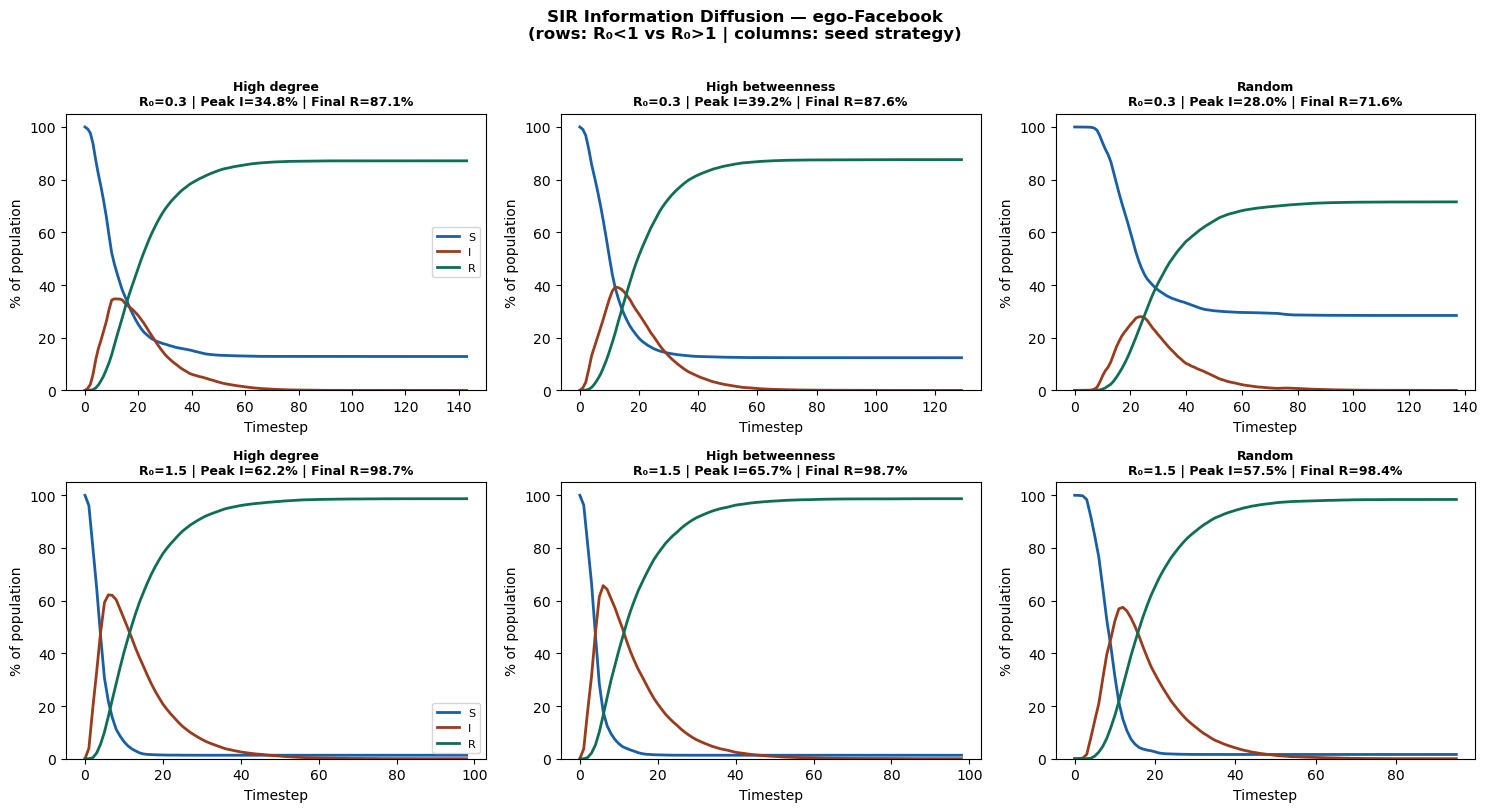

Figure 6 saved.


In [12]:
# === SIR visualization ===
# Two rows: sub-epidemic (R0=0.3) and epidemic (R0=1.5)
# Three columns: one per seed strategy

seed_labels = list(seeds.keys())
colors = {'S': '#185FA5', 'I': '#993C1D', 'R': '#0F6E56'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col_idx, label in enumerate(seed_labels):
    for row_idx, beta in enumerate([BETA_LOW, BETA_HIGH]):
        ax  = axes[row_idx][col_idx]
        res = sir_results[label][beta]
        t   = range(len(res['S']))

        for compartment in ['S', 'I', 'R']:
            ax.plot(t, [v/N*100 for v in res[compartment]],
                    color=colors[compartment], linewidth=2, label=compartment)

        r0 = beta / GAMMA
        final_r = res['R'][-1] / N * 100
        peak_i  = max(res['I']) / N * 100

        ax.set_title(f"{label.split('(')[0].strip()}\nR₀={r0:.1f} | Peak I={peak_i:.1f}% | Final R={final_r:.1f}%",
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Timestep')
        ax.set_ylabel('% of population')
        ax.set_ylim(0, 105)
        if col_idx == 0:
            ax.legend(fontsize=8)

plt.suptitle('SIR Information Diffusion — ego-Facebook\n(rows: R₀<1 vs R₀>1 | columns: seed strategy)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig6_sir_diffusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

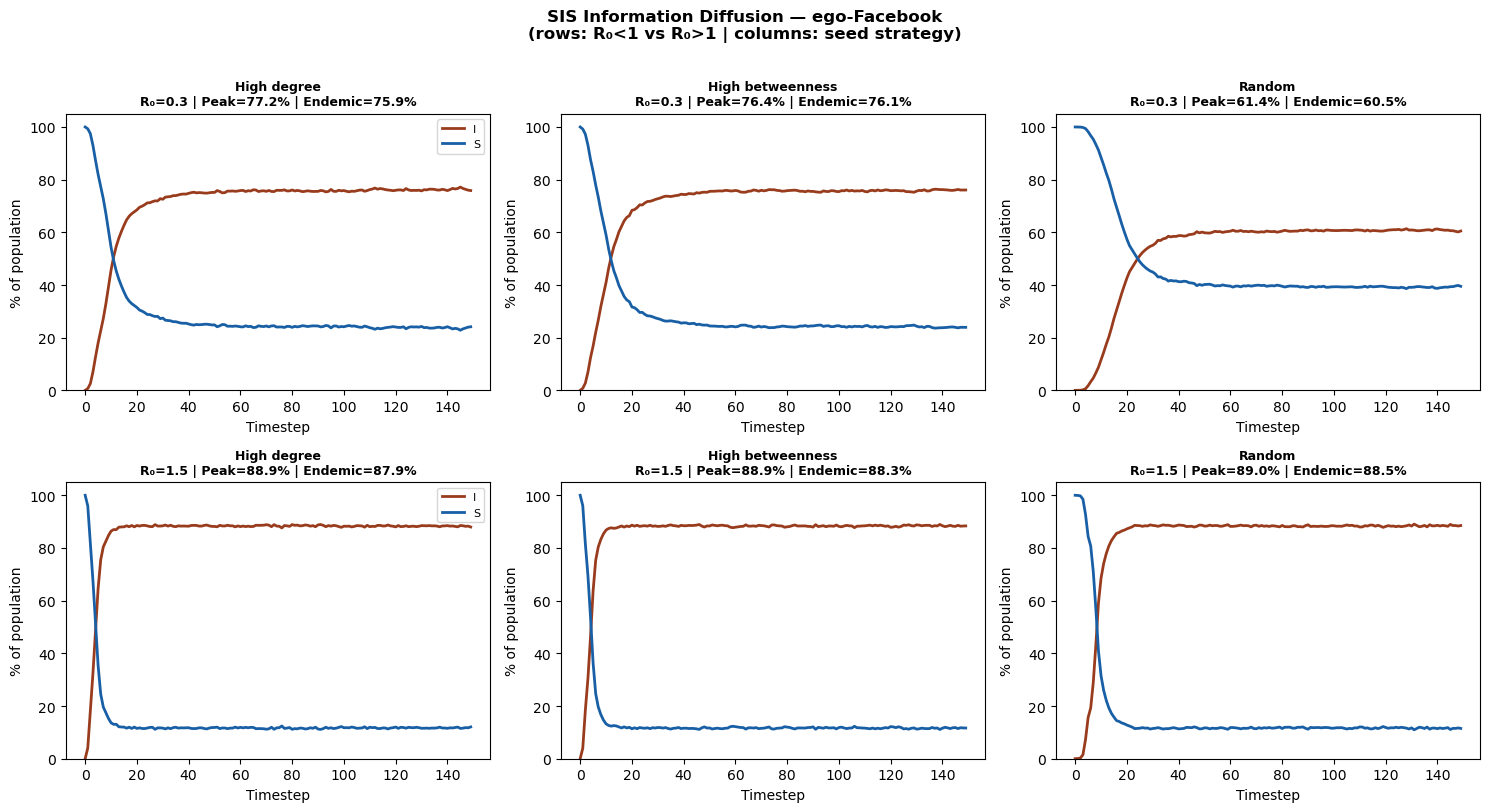

Figure 7 saved.


In [13]:
# === SIS visualization ===

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col_idx, label in enumerate(seed_labels):
    for row_idx, beta in enumerate([BETA_LOW, BETA_HIGH]):
        ax  = axes[row_idx][col_idx]
        res = sis_results[label][beta]
        t   = range(len(res['S']))

        ax.plot(t, [v/N*100 for v in res['I']], color='#993C1D', linewidth=2, label='I')
        ax.plot(t, [v/N*100 for v in res['S']], color='#185FA5', linewidth=2, label='S')

        r0       = beta / GAMMA
        endemic  = res['I'][-1] / N * 100
        peak_i   = max(res['I']) / N * 100

        ax.set_title(f"{label.split('(')[0].strip()}\nR₀={r0:.1f} | Peak={peak_i:.1f}% | Endemic={endemic:.1f}%",
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Timestep')
        ax.set_ylabel('% of population')
        ax.set_ylim(0, 105)
        if col_idx == 0:
            ax.legend(fontsize=8)

plt.suptitle('SIS Information Diffusion — ego-Facebook\n(rows: R₀<1 vs R₀>1 | columns: seed strategy)',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig7_sis_diffusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

In [14]:
# === SIR vs SIS comparison table ===
# Key metrics: peak infected %, timestep of peak, final recovered % (SIR), endemic level (SIS)

print('=== DIFFUSION SUMMARY TABLE ===')
print()

rows = []
for label in seed_labels:
    short_label = label.split('(')[0].strip()
    for beta in [BETA_LOW, BETA_HIGH]:
        r0 = beta / GAMMA

        sir = sir_results[label][beta]
        sis = sis_results[label][beta]

        sir_peak     = max(sir['I']) / N * 100
        sir_peak_t   = np.argmax(sir['I'])
        sir_final_r  = sir['R'][-1] / N * 100

        sis_peak     = max(sis['I']) / N * 100
        sis_endemic  = sis['I'][-1] / N * 100

        rows.append({
            'Seed'          : short_label,
            'R₀'            : r0,
            'SIR peak I%'   : round(sir_peak, 2),
            'SIR peak time' : int(sir_peak_t),
            'SIR final R%'  : round(sir_final_r, 2),
            'SIS peak I%'   : round(sis_peak, 2),
            'SIS endemic I%': round(sis_endemic, 2),
        })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
print()
print('Interpretation:')
print('  When R₀ < 1: infection dies out regardless of seed — epidemic threshold not reached.')
print('  When R₀ > 1: seed centrality matters. High-degree and high-betweenness seeds')
print('  infect a larger final fraction and reach peak faster.')
print('  SIS endemic level at R₀ > 1 reflects the theoretical endemic equilibrium:')
print('  fraction infected = 1 - gamma/beta = 1 - 1/R₀.')

=== DIFFUSION SUMMARY TABLE ===

            Seed  R₀  SIR peak I%  SIR peak time  SIR final R%  SIS peak I%  SIS endemic I%
     High degree 0.3        34.76             11         87.13        77.17           75.86
     High degree 1.5        62.19              6         98.67        88.87           87.94
High betweenness 0.3        39.23             12         87.59        76.36           76.06
High betweenness 1.5        65.69              6         98.68        88.90           88.34
          Random 0.3        27.98             24         71.55        61.37           60.49
          Random 1.5        57.46             12         98.39        89.02           88.49

Interpretation:
  When R₀ < 1: infection dies out regardless of seed — epidemic threshold not reached.
  When R₀ > 1: seed centrality matters. High-degree and high-betweenness seeds
  infect a larger final fraction and reach peak faster.
  SIS endemic level at R₀ > 1 reflects the theoretical endemic equilibrium:
  fracti

Running R₀ sweep...


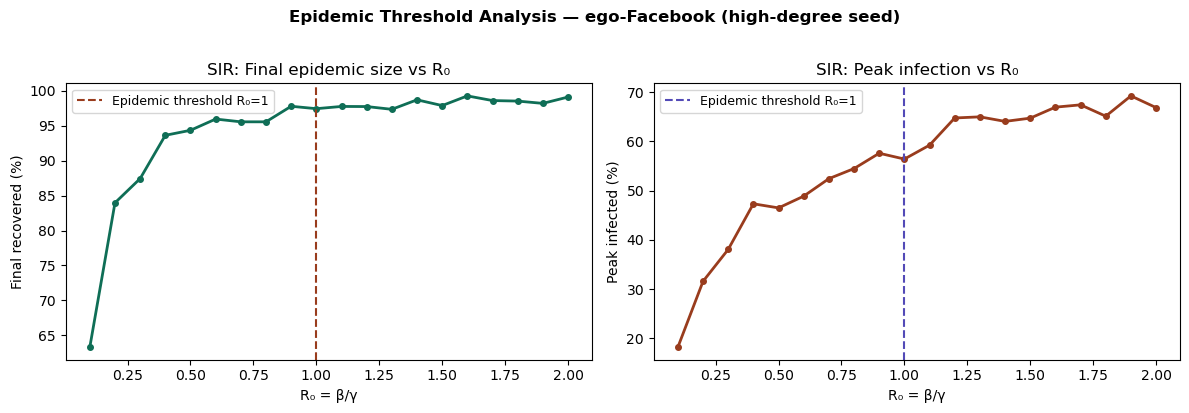

Figure 8 saved.


In [15]:
# === R₀ sweep — how epidemic size scales with infection rate ===
# This shows the epidemic threshold clearly: below R₀=1, near-zero spread.
# Above R₀=1, epidemic size grows rapidly.
# We use the high-degree seed for this sweep.

beta_values = np.linspace(0.01, 0.20, 20)
final_r_sweep = []
peak_i_sweep  = []

print('Running R₀ sweep...')
for beta in beta_values:
    runs = [simulate_SIR(G, [seed_degree], beta=beta, gamma=GAMMA, max_steps=MAX_STEPS)
            for _ in range(3)]
    avg_final_r = np.mean([r['R'][-1] for r in runs]) / N * 100
    avg_peak_i  = np.mean([max(r['I']) for r in runs]) / N * 100
    final_r_sweep.append(avg_final_r)
    peak_i_sweep.append(avg_peak_i)

r0_values = beta_values / GAMMA

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(r0_values, final_r_sweep, color='#0F6E56', linewidth=2, marker='o', markersize=4)
axes[0].axvline(1.0, color='#993C1D', linestyle='--', linewidth=1.5, label='Epidemic threshold R₀=1')
axes[0].set_xlabel('R₀ = β/γ')
axes[0].set_ylabel('Final recovered (%)')
axes[0].set_title('SIR: Final epidemic size vs R₀')
axes[0].legend(fontsize=9)

axes[1].plot(r0_values, peak_i_sweep, color='#993C1D', linewidth=2, marker='o', markersize=4)
axes[1].axvline(1.0, color='#534AB7', linestyle='--', linewidth=1.5, label='Epidemic threshold R₀=1')
axes[1].set_xlabel('R₀ = β/γ')
axes[1].set_ylabel('Peak infected (%)')
axes[1].set_title('SIR: Peak infection vs R₀')
axes[1].legend(fontsize=9)

plt.suptitle('Epidemic Threshold Analysis — ego-Facebook (high-degree seed)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig8_r0_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

Running community-level diffusion tracking...


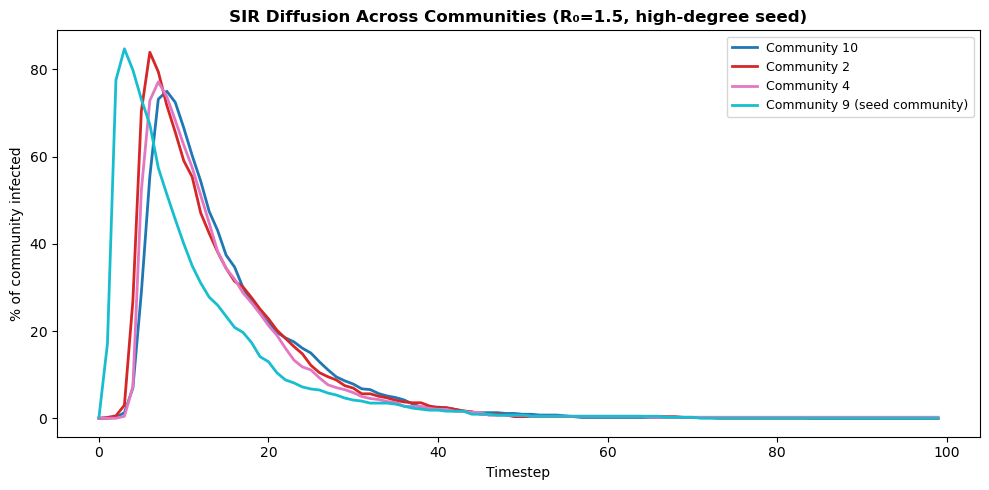

Figure 9 saved.

Interpretation:
  The seed community gets infected first and fastest.
  Spread to other communities is delayed — community boundaries slow diffusion.
  This directly validates the community structure found in Part C:
  strong communities = slower cross-community information flow.


In [16]:
# === Community-level diffusion analysis ===
# How does information spread across community boundaries?
# We track what fraction of each Louvain community gets infected over time.
# This links the diffusion analysis back to the community detection research.

def simulate_SIR_with_community_tracking(G, seed_nodes, partition, beta=0.15,
                                          gamma=0.10, max_steps=100):
    state = {n: 'S' for n in G.nodes()}
    for n in seed_nodes:
        state[n] = 'I'

    # Get community of seed
    seed_comm = partition[seed_nodes[0]]

    # Communities to track: seed community + 3 largest others
    comm_sizes = {}
    for n, c in partition.items():
        comm_sizes[c] = comm_sizes.get(c, 0) + 1
    top_comms = sorted(comm_sizes.items(), key=lambda x: -x[1])[:4]
    tracked   = [c for c, _ in top_comms]
    if seed_comm not in tracked:
        tracked[3] = seed_comm

    comm_infected = {c: [] for c in tracked}

    for _ in range(max_steps):
        for c in tracked:
            members  = [n for n, pc in partition.items() if pc == c and n in G.nodes()]
            infected = sum(1 for n in members if state[n] == 'I') / max(len(members), 1) * 100
            comm_infected[c].append(infected)

        if sum(1 for v in state.values() if v == 'I') == 0:
            break

        new_infected  = set()
        new_recovered = set()
        for node in G.nodes():
            if state[node] == 'I':
                for nbr in G.neighbors(node):
                    if state[nbr] == 'S' and np.random.random() < beta:
                        new_infected.add(nbr)
                if np.random.random() < gamma:
                    new_recovered.add(node)
        for n in new_infected:  state[n] = 'I'
        for n in new_recovered: state[n] = 'R'

    return comm_infected, tracked, seed_comm

print('Running community-level diffusion tracking...')
comm_infected, tracked_comms, seed_comm = simulate_SIR_with_community_tracking(
    G, [seed_degree], louvain_partition, beta=BETA_HIGH, gamma=GAMMA
)

fig, ax = plt.subplots(figsize=(10, 5))
cmap_c = plt.cm.get_cmap('tab10', len(tracked_comms))

for i, comm in enumerate(tracked_comms):
    vals = comm_infected[comm]
    label = f'Community {comm}'
    if comm == seed_comm:
        label += ' (seed community)'
    ax.plot(range(len(vals)), vals, color=cmap_c(i), linewidth=2, label=label)

ax.set_xlabel('Timestep')
ax.set_ylabel('% of community infected')
ax.set_title('SIR Diffusion Across Communities (R₀=1.5, high-degree seed)',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig9_community_diffusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 saved.')
print()
print('Interpretation:')
print('  The seed community gets infected first and fastest.')
print('  Spread to other communities is delayed — community boundaries slow diffusion.')
print('  This directly validates the community structure found in Part C:')
print('  strong communities = slower cross-community information flow.')

In [17]:
# === Update the saved data with link prediction and diffusion results ===

data['link_prediction_results'] = lp_df
data['sir_results']             = sir_results
data['sis_results']             = sis_results
data['r0_sweep']                = {'r0': r0_values, 'final_r': final_r_sweep, 'peak_i': peak_i_sweep}
data['diffusion_params']        = {'beta_low': BETA_LOW, 'beta_high': BETA_HIGH, 'gamma': GAMMA}
data['seed_nodes']              = {'degree': seed_degree, 'betweenness': seed_btw, 'random': seed_random}
data['N_nodes']                 = N

with open('louvainnet_data.pkl', 'wb') as f:
    pickle.dump(data, f)

print('louvainnet_data.pkl updated with link prediction and diffusion results.')

louvainnet_data.pkl updated with link prediction and diffusion results.


In [18]:
# === Extended results summary ===
print('=' * 60)
print('EXTENDED ANALYSIS SUMMARY')
print('=' * 60)
print()
print('Link Prediction (10% held-out edges, hard negatives):')
print(lp_df.to_string())
print()
print('Information Diffusion Parameters:')
print(f'  beta_low={BETA_LOW} (R₀={BETA_LOW/GAMMA:.1f}), beta_high={BETA_HIGH} (R₀={BETA_HIGH/GAMMA:.1f}), gamma={GAMMA}')
print()
print('SIR — High-degree seed, R₀=1.5:')
sir_hd_high = sir_results[seed_labels[0]][BETA_HIGH]
print(f'  Peak infected : {max(sir_hd_high["I"])/N*100:.1f}%')
print(f'  Final recovered: {sir_hd_high["R"][-1]/N*100:.1f}%')
print()
print('Figures produced: fig5_link_prediction, fig6_sir_diffusion,')
print('                  fig7_sis_diffusion, fig8_r0_sweep, fig9_community_diffusion')
print('=' * 60)

EXTENDED ANALYSIS SUMMARY

Link Prediction (10% held-out edges, hard negatives):
                  AUC-ROC  Avg Precision
Method                                  
Common Neighbors   0.9584         0.9530
Jaccard            0.9344         0.9316
Adamic-Adar        0.9641         0.9616

Information Diffusion Parameters:
  beta_low=0.03 (R₀=0.3), beta_high=0.15 (R₀=1.5), gamma=0.1

SIR — High-degree seed, R₀=1.5:
  Peak infected : 62.2%
  Final recovered: 98.7%

Figures produced: fig5_link_prediction, fig6_sir_diffusion,
                  fig7_sis_diffusion, fig8_r0_sweep, fig9_community_diffusion
